# Анализ строительной отрасли МСП России (2021-2025)
## Цель исследования:
* **Оценка финансовой устойчивости и рентабельности строительного МСП в России в период макроэкономических шоков (2021–2025 гг.).**
## Описание данных
* **Источники**: Реестр МСП + финансовая отчетность (EBIT) ФНС.
* **Период**: 2021-2025 гг.
* **Объем выборки**: 8065 компаний
* **Ключевые метрики**: EBIT

## Методология
* Использованы медианные значения для устойчивости к выбросам
* Анализ по сегментам: малые vs средние предприятия
* Географическая стратификация по регионам

## Ограничения исследования
* Не учтена инфляция
* Малая выборка по некоторым регионам
* Неизвестны причины закрытия компаний

## Ключевой вывод
**Отрасль в кризисе**:
* В 2025 г. медианная EBIT упала до минимума за 5 лет, 
* В 2025 г. доля убыточных компаний выросла до 25%.
* С 2021 г. 50% компаний сократили прибыль.
* Средние предприятия стабильно теряют рентабельность (падение медианы на **24%** с 2021 г.)
* **Главный вывод.** Эпоха роста строительного МСП за счет массового спроса и дешевой ипотеки закончилась. Выживают и зарабатывают только компании, занимающиеся государственными заказами и инфраструктурными проектами или работающие в нишах с низкой конкуренцией.

# Загрузка данных

In [1]:
import numpy as np
import pandas as pd

In [2]:
EBITs: pd.DataFrame = pd.read_csv("datasets/EBITs.csv")
EBITs.sample(3)

,ENN,2021ebit,2021payable,2021receivable,2022ebit,2022payable,2022receivable,2023ebit,2023payable,2023receivable,2024ebit,2024payable,2024receivable,2025ebit,2025payable,2025receivable
556,5702004012,-583.0,NaN,0.0,735.0,NaN,0.0,513.0,NaN,0.0,2128.0,NaN,0.0,924.0,0.0,0.0
7191,6450066475,67017.0,NaN,15.0,18285.0,NaN,1.0,32169.0,NaN,0.0,13781.0,NaN,NaN,34208.0,0.0,0.0
1624,5610160710,20739.0,NaN,119.0,6722.0,NaN,114.0,415.0,NaN,2.0,10000.0,NaN,604.0,-5391.0,0.0,2639.0


In [3]:
REGISTRY: pd.DataFrame = pd.read_csv("datasets/ClearedRegistry.csv")
REGISTRY.sample(2)

,Наименование / ФИО,Тип субъекта,Категория,ИНН,Регион,Город,Населенный пункт,Дата включения в реестр,Наличие лицензий,Среднесписочная численность работников за предшествующий календарный год
5699,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""СТАЛ...",Юридическое лицо,Среднее предприятие,9710047602,20 - Чеченская Республика,г Грозный,NaN,10.02.2018,Нет,37.0
750,"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""АЛЬЯ...",Юридическое лицо,Малое предприятие,7326046099,73 - Ульяновская область,г Ульяновск,NaN,01.08.2016,Нет,6.0


In [4]:
REGISTRY.rename(
    columns=
    {
        "Среднесписочная численность работников за предшествующий календарный год": "workers",
        "Дата включения в реестр": "registry date",
        "Наименование / ФИО": "company",
        "Наличие лицензий": "license",
        "Категория": "category",
        "Регион": "region",
        "Город": "city",
        "ИНН": "enn"
    },
    inplace=True
)

In [5]:
REGISTRY.describe()

,enn,workers
count,8.927000e+03,8881.000000
mean,5.429358e+09,30.139399
std,2.567626e+09,35.410287
min,1.010092e+08,0.000000
25%,3.257040e+09,9.000000
50%,5.906049e+09,20.000000
75%,7.717769e+09,37.000000
max,9.731095e+09,250.000000


In [6]:
REGISTRY['enn'] = REGISTRY['enn'].astype(int)

In [7]:
REGISTRY.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8927 entries, 0 to 8926
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   company           8927 non-null   object 
 1   Тип субъекта      8927 non-null   object 
 2   category          8927 non-null   object 
 3   enn               8927 non-null   int64  
 4   region            8927 non-null   object 
 5   city              5730 non-null   object 
 6   Населенный пункт  671 non-null    object 
 7   registry date     8927 non-null   object 
 8   license           8927 non-null   object 
 9   workers           8881 non-null   float64
dtypes: float64(1), int64(1), object(8)
memory usage: 697.6+ KB


In [8]:
registry = REGISTRY.merge(EBITs, left_on='enn', right_on='ENN', how='inner').drop(columns="ENN")

In [9]:
registry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8065 entries, 0 to 8064
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   company           8065 non-null   object 
 1   Тип субъекта      8065 non-null   object 
 2   category          8065 non-null   object 
 3   enn               8065 non-null   int64  
 4   region            8065 non-null   object 
 5   city              5234 non-null   object 
 6   Населенный пункт  591 non-null    object 
 7   registry date     8065 non-null   object 
 8   license           8065 non-null   object 
 9   workers           8034 non-null   float64
 10  2021ebit          7452 non-null   float64
 11  2021payable       3350 non-null   float64
 12  2021receivable    4770 non-null   float64
 13  2022ebit          7630 non-null   float64
 14  2022payable       3484 non-null   float64
 15  2022receivable    4988 non-null   float64
 16  2023ebit          7168 non-null   float64


In [10]:
ebit_cols = ["2021ebit", "2022ebit", "2023ebit", "2024ebit", "2025ebit"]
registry[ebit_cols].describe()

,2021ebit,2022ebit,2023ebit,2024ebit,2025ebit
count,7.452000e+03,7.630000e+03,7.168000e+03,6.663000e+03,6.159000e+03
mean,1.369987e+04,1.389637e+04,1.749110e+04,2.036463e+04,1.860158e+04
std,1.038510e+05,1.050958e+05,9.400317e+04,1.297181e+05,1.205103e+05
min,-7.892030e+05,-1.585207e+06,-1.707200e+06,-3.733865e+06,-1.088604e+06
25%,5.367500e+02,2.662500e+02,2.347500e+02,1.045000e+02,-9.000000e+00
50%,3.232500e+03,3.053500e+03,3.483500e+03,3.495000e+03,2.717000e+03
75%,1.151950e+04,1.283050e+04,1.496250e+04,1.741150e+04,1.538950e+04
max,7.007719e+06,5.025550e+06,2.266259e+06,3.456365e+06,3.089335e+06


# Графики

In [11]:
import matplotlib.pyplot as plt

int_years = list(range(2021, 2026))
str_years = list(map(str, int_years))

def prepare_plt(y, size: tuple[int] = (8, 5), **kwargs) -> None:
    plt.figure(figsize=size)
    plt.grid(linestyle="--", alpha=0.5)
    plt.plot(str_years, y,**kwargs)
    plt.xlabel("Год")

## Медианная EBIT по годам

In [12]:
# Объединение колонок с EBIT в одну
ebit_long = registry[["category"] + ebit_cols].melt(
    id_vars=["category"],
    value_vars=ebit_cols,
    var_name='year',
    value_name='ebit'
)
ebit_long["ebit"].dropna(inplace=True)

In [13]:
median_ebit_by_year = ebit_long.groupby('year')['ebit'].median().reset_index()

Text(0, 0.5, 'Медианная EBIT, тыс. руб.')

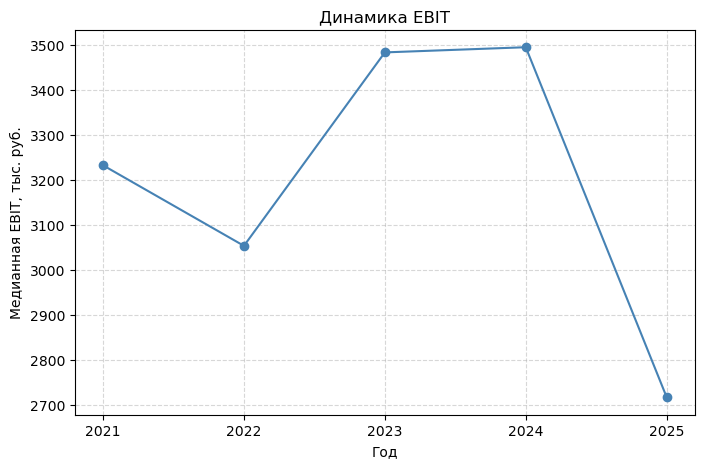

In [14]:
prepare_plt(median_ebit_by_year['ebit'], color="steelblue", marker="o")
plt.title("Динамика EBIT")
plt.ylabel("Медианная EBIT, тыс. руб.")

Резкое падение EBIT в 2025 г. говорит о сильном снижении рентабельности бизнеса.

## Доля убыточных компаний по годам

In [15]:
loss_share = []
for col in ebit_cols:
    data = registry[col].dropna()
    share = (data < 0).mean() * 100  # процент убыточных компаний в году
    loss_share.append(share)

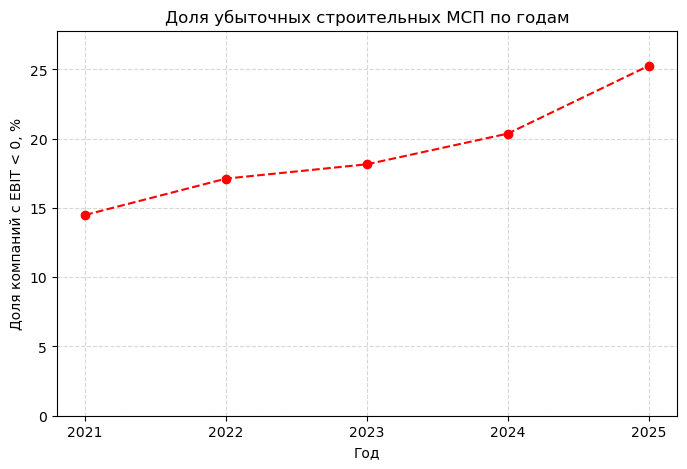

In [16]:
prepare_plt(loss_share, color="red", linestyle="--", marker="o")

plt.title('Доля убыточных строительных МСП по годам')
plt.ylabel('Доля компаний с EBIT < 0, %')

plt.ylim(0, max(loss_share)*1.1)
plt.show()

## Сравнение прибыльности малого и среднего бизнеса

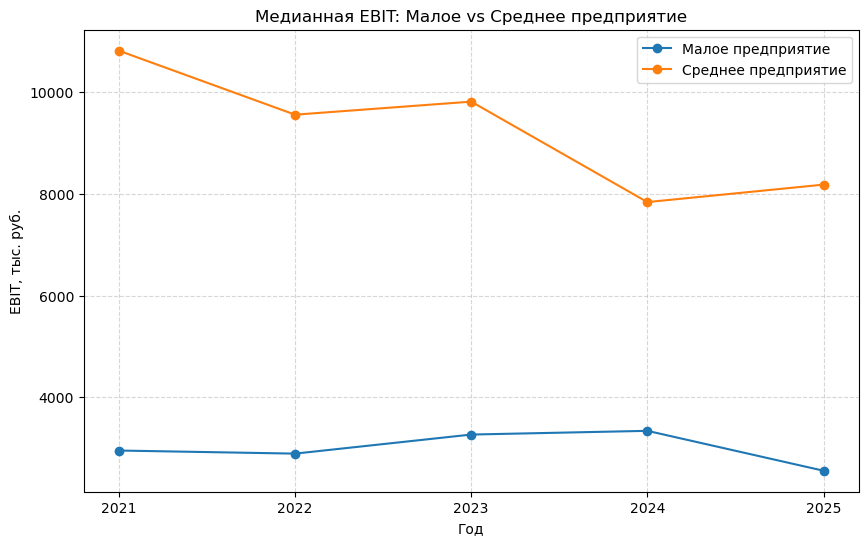

In [17]:
# Группируем по году и категории компании
median_ebit_by_type = ebit_long.groupby(["year", "category"])["ebit"].median().reset_index()

plt.figure(figsize=(10, 6))
plt.grid(linestyle="--", alpha=0.5)

for subtype in median_ebit_by_type["category"].unique():
    data = median_ebit_by_type.query("category == @subtype")
    plt.plot(str_years, data['ebit'], marker='o', label=subtype)

plt.xlabel('Год')
plt.ylabel('EBIT, тыс. руб.')
plt.title('Медианная EBIT: Малое vs Среднее предприятие')

plt.legend()
plt.show()

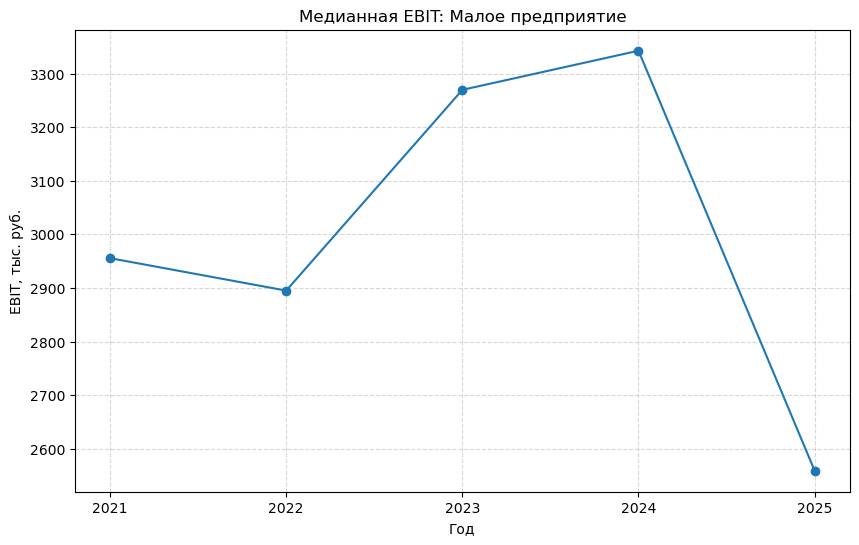

In [18]:
data = median_ebit_by_type.query("category == 'Малое предприятие'")

prepare_plt(data['ebit'], size=(10, 6), marker='o', label=subtype)
plt.title('Медианная EBIT: Малое предприятие')
plt.ylabel('EBIT, тыс. руб.')

plt.show()

## Распределение EBIT по регионам в 2025 г.

In [19]:
median_ebit_by_region = registry.groupby('region')['2025ebit'].median().sort_values(ascending=False)[:10]

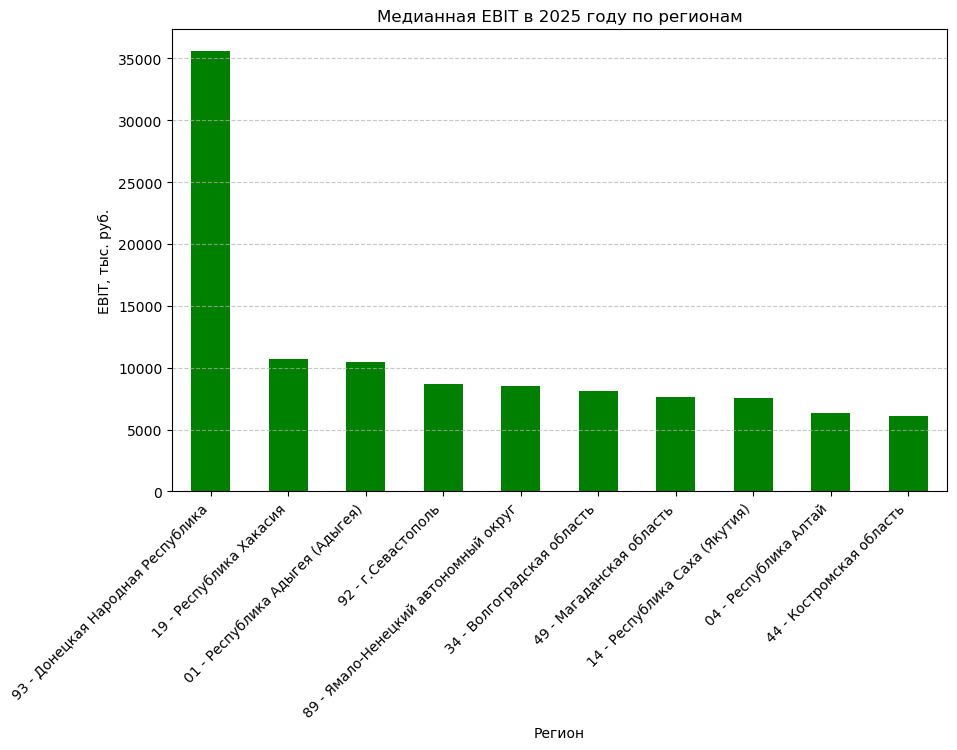

In [20]:
plt.figure(figsize=(10, 6))
median_ebit_by_region.plot(kind='bar', color='green')

plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha='right')

plt.xlabel("Регион")
plt.ylabel('EBIT, тыс. руб.')
plt.title('Медианная EBIT в 2025 году по регионам')

plt.show()

## Рост EBIT компаний в % с 2022-го по 2025-ый гг.

In [21]:
mask: pd.Series = registry["2021ebit"].notna() & registry["2021ebit"]!=0
for col in ebit_cols[1:]:
    mask &= registry[col].notna()

In [22]:
df_growth = registry[mask].copy()

df_growth["ebit_growth_pct"] = (df_growth["2025ebit"]-df_growth["2021ebit"]) / np.abs(df_growth["2021ebit"]) * 100

df_growth.dropna(subset="ebit_growth_pct", inplace=True)

In [23]:
df_growth["ebit_growth_pct"].describe()

count    5.505000e+03
mean    -3.804003e+02
std      3.541362e+04
min     -1.403600e+06
25%     -9.715517e+01
50%     -5.714286e+00
75%      2.052028e+02
max      5.813444e+05
Name: ebit_growth_pct, dtype: float64

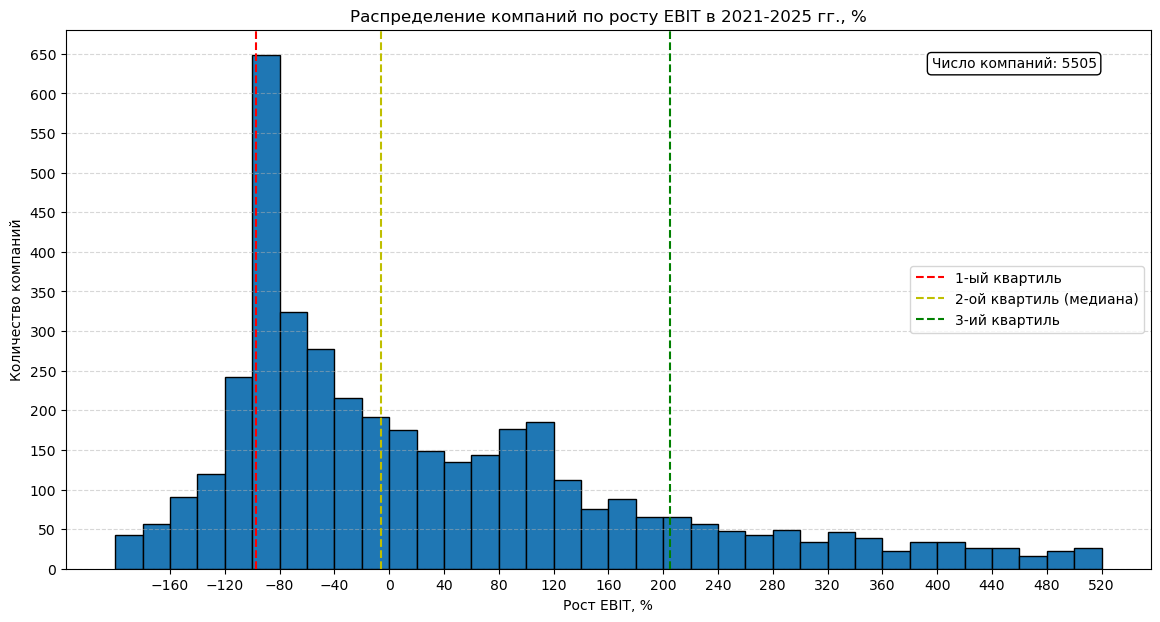

In [24]:
plt.figure(figsize=(14, 7))
plt.hist(df_growth["ebit_growth_pct"], np.arange(-200, 540, 20), edgecolor="black")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(np.arange(-160, 540, 40))
plt.yticks(np.arange(0, 700, 50))

plt.axvline(x=df_growth["ebit_growth_pct"].quantile(0.25),
            color="r", linestyle="--", label='1-ый квартиль')
plt.axvline(x=df_growth["ebit_growth_pct"].median(),
            color="y", linestyle="--", label="2-ой квартиль (медиана)")
plt.axvline(x=df_growth["ebit_growth_pct"].quantile(0.75),
            color='g', linestyle='--', label="3-ий квартиль")

plt.xlabel('Рост EBIT, %')
plt.ylabel('Количество компаний')
plt.title('Распределение компаний по росту EBIT в 2021-2025 гг., %')
plt.text(
    x=0.95, y=0.95,
    transform=plt.gca().transAxes,
    s=f"Число компаний: {len(df_growth)}",
    bbox=dict(boxstyle='round', facecolor='white'),
    verticalalignment='top', horizontalalignment='right'
)

plt.legend()
plt.show()

## Анализ задолженности

In [25]:
pay_cols = ["2021payable", "2022payable", "2023payable", "2024payable", "2025payable"]
pay_long = registry[pay_cols].melt(
    value_vars=pay_cols,
    var_name="year",
    value_name="pay"
).dropna()

In [26]:
median_pay_by_year = pay_long.groupby("year")["pay"].median().reset_index()

Text(0.5, 1.0, 'Динамика погашения задолженностей')

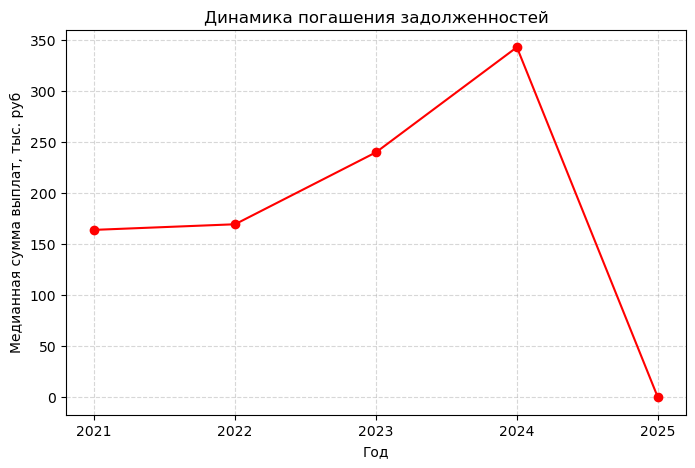

In [27]:
prepare_plt(median_pay_by_year["pay"], marker="o", color="r")
plt.ylabel("Медианная сумма выплат, тыс. руб")
plt.title("Динамика погашения задолженностей")

In [28]:
pay_median_share = []
for i in range(len(pay_cols)):
    data = registry[[ ebit_cols[i], pay_cols[i] ]].dropna()
    data = data[ data[ebit_cols[i]] > 0 ]
    share = data[pay_cols[i]] / data[ebit_cols[i]] * 100
    share = share.median()
    pay_median_share.append(share)

Text(0.5, 1.0, 'Отношение выплат по долгу к EBIT')

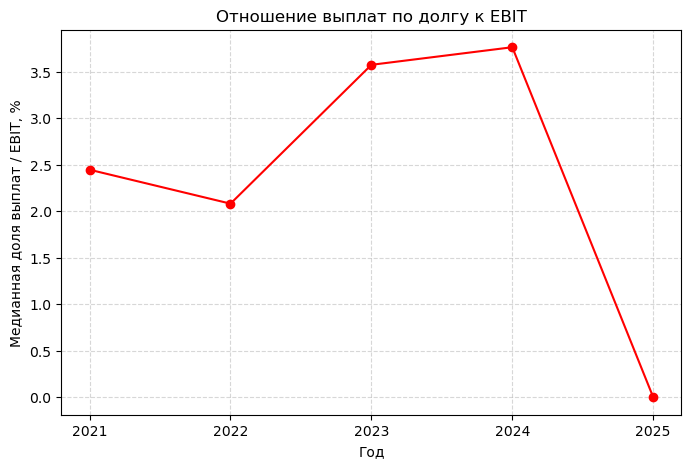

In [29]:
prepare_plt(pay_median_share, marker="o", color="r")
plt.ylabel("Медианная доля выплат / EBIT, %")
plt.title("Отношение выплат по долгу к EBIT")

# Выводы и гипотезы

* С 2021-го по 2022 гг. медианная EBIT падала вследствие влияния пандемии и санкций, повлиявших на рост себестоимости строительства и падение спроса на него.
* Пик операционной прибыльности МСП пришелся на 2023 г, когда экономическая ситуация стабилизировалась.
* Из-за сворачивания программы льготной ипотеки и ужесточения ДКП в конце 2024 г., приведших к снижению спроса на строительство и повышению его себестоимости в 2025 г., произошёл резкий обвал медианы и рост доли убыточных предприятий с ~18% в 2023 г. до ~25%.
* За 2024-2025 гг. доля убыточных компаний выросла сильнее всего -- сразу на 5%.

* Медиана EBIT средних предприятий планомерно снижалась или стагнировала все 5 лет, упав более чем на 20%. Возможно, это произошло по причине длительного строительного цикла (средние предприятия не успели воспользоваться бумом спроса на льготную ипотку в 2021-2024 гг.) и усилением конкуренции с крупным бизнесом за государственные и относительно крупные заказы.
* У малых предприятий в 2021-2024 гг. наблюдается бурный рост медианной EBIT из-за бума спроса на индивидуальное жилищное строительство (ИЖС) по льготным ипотечным программам. Возможно, темпы роста также связаны с эффектом низкой базой после пандемии.

* Регионом, ставшим лидером по медианной EBIT, является ДНР. Это обусловлено масштабными госзаказами по восстановлению повреждённых и устаревших инфраструктуры, социальных объектов и жилья и строительством новых объектов.
* В топ-10 также вошли:
  * Республика Хакасия (~10 млн руб.) -- промышленный регион
  * Ямало-Ненецкий АО (~8.5 млн руб.) -- нефтегазовый регион
  * Магаданская область (~7.5 млн руб.) -- золотодобывающий регион
  * Республика Саха (~7.5 млн руб.) -- регион добычи алмазов, угля, нефти и золота
* В этих регионах активно идёт промышленное строительство, которое имеет повышенную стоимость из-за климатических и географических особенностей.
* Такому составу 10-ки лидирующих регионов способствуют меньшая конкуренция, чем, например, в столичном регионе, (возможное) отсутствие насыщенности рынка, независимость от льготных ипотечных программ и наличие крупных заказов от государства и корпораций.

Распределение роста EBIT строительных МСП за 2021-2025 гг. показывает поляризацию отрасли. За указанный период в течение 5 лет:
* Каждая 4-ая компания стала убыточной.
* Каждая 2-ая компания стала меньше зарабатывать от основной деятельности.
* При этом длинный правый хвост (до +520%) отражает узкий сегмент 'победителей', сконцентрированных в регионах с госзаказом (ДНР, ЯНАО) и нишах инфраструктурного строительства.

# Рекомендации

На основе проведенного анализа, можно сформулировать следующие рекомендации для стейкхолдеров:

### Для банков:
1. **Скоринг.** При оценке строительных МСП необходимо закладывать повышенные риски дефолта для компаний, чья выручка зависит от льготной ипотеки.
1. **Региональная сегментация.** Кредитные лимиты и ставки должны дифференцироваться не только по размеру бизнеса, но и по региону. Компании в некоторых регионах (например, в ДНР) имеют более высокую долговую емкость.
1. **Сегментация клиентской базы МСП.** Разделение строительных компаний на сегменты по структуре заказов (госзаказы, ИЖС, коммерческая недвижимость) с соответствующим риск-менеджментом.

### Для инвесторов:
1. **Переориентация инвестиционной стратегии.** Снижение доли инвестиций в девелоперов массового жилья в пользу компаний, ориентированных на инфраструктурное строительство и госзаказы.
1. **Региональная диверсификация.** Увеличение доли инвестиций в регионы с высокой рентабельностью и низкой конкуренцией.
1. **Фокус на технологические решения.** Инвестирование в компании, внедряющие инновационные технологии, сокращающие циклы строительства и повышающие маржинальность.

### Для самих строительных МСП:
1. **Диверсификация портфеля заказов.** Критически важно избегать зависимости от одного источника дохода (только жилищное строительство или только госзаказы).
1. **Оптимизация издержек.** В условиях роста ключевой ставки необходимо пересмотреть структуру затрат, внедрить проектное управление и автоматизировать процессы для сокращения циклов строительства.
1. **Региональная экспансия.** Расширение деятельности в регионы с высокой рентабельностью и низкой конкуренцией.
1. **Технологическое развитие.** Инвестиции в цифровые решения и современные методы строительства для повышения эффективности и снижения издержек.

In [39]:
# 4. Кластеризация компаний
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(registry[['2025ebit', 'workers']])

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values